# Simulação por Eventos Discretos (DES) de Slotted CSMA/CA

Este notebook implementa uma simulação por eventos discretos (DES) para o protocolo **Slotted CSMA/CA**.

## Métricas de desempenho avaliadas
- Taxa de entrega de pacotes (%)
- Taxa de dados efetiva (bps)
- Latência média (s)
- Ocupação média e máxima dos buffers (quadros)

## Variação experimental
A simulação varia a **carga oferecida por nó** para observar o impacto no desempenho da rede.

## Observação
O modelo implementado é uma versão simplificada de Slotted CSMA/CA, adequada para estudo e análise de desempenho.

## Imports

In [2]:
import heapq
import math
import random
from dataclasses import dataclass, field
from collections import deque
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Configurações gerais

Esta célula define a semente dos geradores de números aleatórios utilizados na simulação. Isso torna os resultados reprodutíveis, permitindo que a análise das métricas de desempenho seja feita sobre o mesmo conjunto de eventos aleatórios em diferentes execuções.

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Estruturas de dados

In [ ]:
# Cria uma classe para representar os eventos da simulação.
# O decorador @dataclass reduz a necessidade de escrever manualmente
# métodos como __init__, tornando a estrutura mais simples.
#
# O parâmetro order=True permite que os eventos sejam comparados e ordenados.
# Porque a simulação por eventos discretos precisa sempre
# executar primeiro o evento com menor tempo.
@dataclass(order=True)
class Event:
    # Instante em que o evento deve ocorrer na simulação.
    # Esse campo participa da ordenação dos eventos.
    time: float

    # Prioridade do evento caso dois eventos ocorram no mesmo instante.
    # Quanto menor o valor, maior a prioridade na fila de eventos.
    priority: int

    # Tipo do evento, por exemplo:
    # chegada de pacote, tentativa de transmissão, fim de transmissão.
    # O compare=False indica que esse campo não será usado para ordenar eventos.
    event_type: str = field(compare=False)

    # Identificador do nó associado ao evento.
    # O valor padrão -1 pode ser usado para eventos que não pertencem
    # diretamente a um nó específico.
    node_id: int = field(compare=False, default=-1)

    # Dicionário para armazenar informações adicionais do evento.
    # Pode guardar, por exemplo, dados do pacote, tempo de geração,
    # número de tentativa ou outras informações auxiliares.
    data: dict = field(compare=False, default_factory=dict)


# Cria uma classe para representar cada nó ou estação da rede.
# Cada nó possui uma fila de pacotes, limite de buffer e informações
# relacionadas ao processo de backoff do CSMA/CA.
class Node:
    def __init__(self, node_id: int, buffer_limit: int):
        # Identificador único do nó na rede.
        self.node_id = node_id

        # Fila de pacotes aguardando transmissão.
        # A estrutura deque é eficiente para inserir no final
        # e remover do início da fila.
        self.queue = deque()

        # Limite máximo de pacotes que podem ficar armazenados no buffer.
        self.buffer_limit = buffer_limit

        # Estágio atual de backoff do nó.
        # Esse valor pode ser aumentado após falhas ou colisões,
        # simulando o aumento da janela de contenção.
        self.backoff_stage = 0

        # Indica se o nó já está em processo de tentativa de transmissão.
        # Isso evita que múltiplas tentativas simultâneas sejam agendadas
        # para o mesmo nó.
        self.attempting = False

        # Armazena o último valor de backoff sorteado.
        # Essa informação é para análise, depuração
        # ou explicação do comportamento da simulação.
        self.last_backoff = None

    # Retorna a quantidade atual de pacotes na fila do nó.
    def buffer_size(self) -> int:
        return len(self.queue)

    # Verifica se ainda há espaço no buffer para aceitar um novo pacote.
    def can_accept_packet(self) -> bool:
        return len(self.queue) < self.buffer_limit

    # Insere um pacote na fila do nó, caso exista espaço disponível.
    # Retorna True se o pacote foi aceito e False se o buffer estava cheio.
    def enqueue_packet(self, packet: dict) -> bool:
        if self.can_accept_packet():
            self.queue.append(packet)
            return True
        return False

    # Consulta o primeiro pacote da fila sem removê-lo.
    # Esse método é útil para verificar qual pacote será transmitido
    # sem alterar o estado da fila.
    def peek_packet(self):
        if self.queue:
            return self.queue[0]
        return None

    # Remove e retorna o primeiro pacote da fila.
    # Esse método é usado quando o pacote foi transmitido com sucesso
    # ou quando precisa sair definitivamente da fila.
    def pop_packet(self):
        if self.queue:
            return self.queue.popleft()
        return None

## Funções auxiliares

In [ ]:
# Gera o intervalo de tempo entre chegadas consecutivas de pacotes.
# A chegada dos pacotes é modelada como um processo de Poisson,
# no qual os intervalos entre chegadas seguem uma distribuição exponencial.
def exp_interarrival(rate: float) -> float:
    """Gera intervalo entre chegadas para processo de Poisson."""

    # Se a taxa de chegada for menor ou igual a zero,
    # não há geração de novos pacotes.
    # Nesse caso, retorna infinito para indicar que a próxima chegada
    # não ocorrerá dentro do tempo útil da simulação.
    if rate <= 0:
        return float("inf")

    # Gera um intervalo aleatório com distribuição exponencial.
    # A média da distribuição exponencial é 1/rate.
    # Exemplo: se rate = 5 pacotes/s, o intervalo médio entre chegadas
    # será de 0,2 segundo.
    return np.random.exponential(1.0 / rate)


# Ajusta um instante de tempo para o próximo slot disponível.
# No Slotted CSMA/CA, as tentativas de transmissão não ocorrem
# em qualquer instante contínuo, mas sim em instantes alinhados aos slots.
def next_slot_time(t: float, slot_time: float) -> float:
    """Retorna o próximo instante alinhado ao slot."""

    # Divide o tempo atual pelo tamanho do slot, arredonda para cima
    # e multiplica novamente pelo tamanho do slot.
    #
    # Isso garante que o evento seja deslocado para o início do próximo slot.
    # Se t já estiver exatamente alinhado ao slot, o próprio t é retornado.
    return math.ceil(t / slot_time) * slot_time


# Calcula a janela de contenção usada no mecanismo de backoff.
# Após colisões ou falhas de acesso ao meio, a janela pode crescer
# exponencialmente, reduzindo a chance de novas colisões.
def contention_window(cw_min: int, backoff_stage: int, max_stage: int) -> int:
    """Janela de contenção com crescimento exponencial limitado."""

    # Limita o estágio de backoff ao valor máximo definido.
    # Isso impede que a janela de contenção cresça indefinidamente.
    stage = min(backoff_stage, max_stage)

    # Calcula a janela de contenção usando crescimento exponencial binário.
    # No estágio 0, CW = cw_min.
    # No estágio 1, CW = 2*cw_min.
    # No estágio 2, CW = 4*cw_min, e assim por diante,
    # até o limite definido por max_stage.
    return cw_min * (2 ** stage)

## Simulador DES

In [ ]:
# Classe principal da simulação do protocolo Slotted CSMA/CA.
# Ela concentra os parâmetros da rede, os nós, a fila de eventos,
# o estado do canal e as métricas de desempenho.
class SlottedCSMACASimulator:
    def __init__(
        self,
        num_nodes: int = 10,
        sim_time: float = 10.0,
        bitrate: float = 1e6,              # Taxa de transmissão do meio em bits por segundo.(1 Mbps)
        packet_size_bits: int = 12000,     # Tamanho de cada pacote em bits.
        slot_time: float = 0.001,          # Duração de cada slot de tempo em segundos.
        arrival_rate_per_node: float = 5.0,# Taxa média de chegada de pacotes por nó.
        cw_min: int = 4,                   # Janela mínima de contenção.
        max_backoff_stage: int = 5,        # Estágio máximo de backoff.
        buffer_limit: int = 50,            # Tamanho máximo do buffer de cada nó.
        propagation_delay: float = 0.0     # Atraso de propagação do meio.
    ):
        # Armazena os parâmetros gerais da simulação.
        self.num_nodes = num_nodes
        self.sim_time = sim_time
        self.bitrate = bitrate
        self.packet_size_bits = packet_size_bits
        self.slot_time = slot_time
        self.arrival_rate_per_node = arrival_rate_per_node
        self.cw_min = cw_min
        self.max_backoff_stage = max_backoff_stage
        self.buffer_limit = buffer_limit
        self.propagation_delay = propagation_delay

        # Calcula o tempo necessário para transmitir um pacote.
        # Fórmula: tempo de transmissão = tamanho do pacote / taxa de transmissão.
        self.tx_time = self.packet_size_bits / self.bitrate

        # Cria a lista de nós da rede.
        # Cada nó recebe um identificador e um limite de buffer.
        self.nodes = [Node(i, buffer_limit) for i in range(num_nodes)]

        # Fila de eventos da simulação.
        # Essa fila será organizada por tempo, usando heapq.
        self.event_queue: List[Event] = []

        # Contador usado para definir prioridade entre eventos.
        # Ele evita conflito quando dois eventos possuem o mesmo tempo.
        self.event_counter = 0

        # Indica até que instante o canal estará ocupado.
        # Se o tempo atual for menor que esse valor, o canal está ocupado.
        self.channel_busy_until = 0.0

        # Métricas principais da simulação.
        self.generated_packets = 0       # Total de pacotes gerados.
        self.delivered_packets = 0       # Total de pacotes entregues com sucesso.
        self.dropped_packets = 0         # Total de pacotes descartados por buffer cheio.
        self.collided_packets = 0        # Total de pacotes envolvidos em colisão.
        self.total_latency = 0.0         # Soma das latências dos pacotes entregues.
        self.total_bits_delivered = 0    # Total de bits entregues com sucesso.

        # Variáveis usadas para calcular ocupação média e máxima dos buffers.
        self.buffer_area = 0.0
        self.last_buffer_update_time = 0.0
        self.max_buffer_occupancy = 0

    # Agenda um novo evento na fila de eventos da simulação.
    def schedule_event(self, time: float, event_type: str, node_id: int = -1, data: dict = None):
        # Caso nenhum dado adicional seja enviado, cria um dicionário vazio.
        if data is None:
            data = {}

        # Incrementa o contador de eventos.
        # Esse contador é usado como prioridade para desempate.
        self.event_counter += 1

        # Insere o evento na fila de prioridade.
        # O heapq garante que o evento com menor tempo será executado primeiro.
        heapq.heappush(
            self.event_queue,
            Event(
                time=time,
                priority=self.event_counter,
                event_type=event_type,
                node_id=node_id,
                data=data
            )
        )

    # Calcula a ocupação total dos buffers da rede.
    # Soma a quantidade de pacotes armazenados em todos os nós.
    def total_buffer_occupancy(self) -> int:
        return sum(node.buffer_size() for node in self.nodes)

    # Atualiza as estatísticas de ocupação dos buffers.
    def update_buffer_statistics(self, current_time: float):
        # Calcula o intervalo de tempo desde a última atualização.
        dt = current_time - self.last_buffer_update_time

        # Se houve avanço no tempo da simulação, acumula a área sob a curva
        # da ocupação dos buffers.
        # Essa área será usada depois para calcular a ocupação média.
        if dt > 0:
            self.buffer_area += self.total_buffer_occupancy() * dt
            self.last_buffer_update_time = current_time

        # Atualiza a maior ocupação observada nos buffers durante a simulação.
        self.max_buffer_occupancy = max(
            self.max_buffer_occupancy,
            self.total_buffer_occupancy()
        )

    # Inicializa a simulação criando o primeiro evento de chegada
    # de pacote para cada nó da rede.
    def initialize(self):
        for node_id in range(self.num_nodes):
            # Sorteia o primeiro instante de chegada de pacote para o nó.
            t0 = exp_interarrival(self.arrival_rate_per_node)

            # Agenda a chegada apenas se ela ocorrer dentro do tempo simulado.
            if t0 <= self.sim_time:
                self.schedule_event(t0, "packet_arrival", node_id=node_id)

    # Executa a simulação até acabar o tempo ou até não haver mais eventos.
    def run(self) -> Dict[str, Any]:
        # Cria os eventos iniciais.
        self.initialize()

        # Enquanto houver eventos na fila, a simulação continua.
        while self.event_queue:
            # Remove da fila o próximo evento em ordem cronológica.
            event = heapq.heappop(self.event_queue)

            # Se o evento ultrapassa o tempo máximo de simulação,
            # a execução é encerrada.
            if event.time > self.sim_time:
                break

            # Atualiza as estatísticas de buffer no instante do evento.
            self.update_buffer_statistics(event.time)

            # Trata evento de chegada de pacote.
            if event.event_type == "packet_arrival":
                self.handle_packet_arrival(event)

            # Trata evento de tentativa de transmissão.
            elif event.event_type == "attempt_tx":
                self.handle_attempt_tx(event)

            # Trata evento de fim de transmissão bem-sucedida.
            elif event.event_type == "end_tx_success":
                self.handle_end_tx_success(event)

            # Trata evento de fim de transmissão com colisão.
            elif event.event_type == "end_tx_collision":
                self.handle_end_tx_collision(event)

        # Atualiza as estatísticas até o tempo final da simulação.
        self.update_buffer_statistics(self.sim_time)

        # Calcula a taxa de entrega de pacotes em porcentagem.
        delivery_rate = (
            self.delivered_packets / self.generated_packets * 100.0
        ) if self.generated_packets > 0 else 0.0

        # Calcula a vazão efetiva da rede em bits por segundo.
        throughput_bps = self.total_bits_delivered / self.sim_time

        # Calcula a latência média dos pacotes entregues.
        avg_latency = (
            self.total_latency / self.delivered_packets
        ) if self.delivered_packets > 0 else 0.0

        # Calcula a ocupação média dos buffers.
        avg_buffer_occupancy = self.buffer_area / self.sim_time

        # Retorna as métricas finais da simulação.
        return {
            "num_nodes": self.num_nodes,
            "arrival_rate_per_node": self.arrival_rate_per_node,
            "generated_packets": self.generated_packets,
            "delivered_packets": self.delivered_packets,
            "dropped_packets": self.dropped_packets,
            "collided_packets": self.collided_packets,
            "delivery_rate_percent": delivery_rate,
            "throughput_bps": throughput_bps,
            "avg_latency_s": avg_latency,
            "avg_buffer_occupancy": avg_buffer_occupancy,
            "max_buffer_occupancy": self.max_buffer_occupancy
        }

    # Agenda a próxima chegada de pacote para um nó.
    def schedule_next_arrival(self, current_time: float, node_id: int):
        # O próximo tempo de chegada é o tempo atual mais um intervalo
        # aleatório gerado pela distribuição exponencial.
        next_t = current_time + exp_interarrival(self.arrival_rate_per_node)

        # Agenda o próximo pacote apenas se estiver dentro do tempo simulado.
        if next_t <= self.sim_time:
            self.schedule_event(next_t, "packet_arrival", node_id=node_id)

    # Trata o evento de chegada de um novo pacote em determinado nó.
    def handle_packet_arrival(self, event: Event):
        # Identifica o nó que recebeu o pacote.
        node = self.nodes[event.node_id]

        # Incrementa o número total de pacotes gerados.
        self.generated_packets += 1

        # Cria o pacote com seu instante de chegada e tamanho em bits.
        # O arrival_time será usado depois para calcular a latência.
        packet = {
            "arrival_time": event.time,
            "size_bits": self.packet_size_bits
        }

        # Tenta inserir o pacote no buffer do nó.
        accepted = node.enqueue_packet(packet)

        # Se o buffer estiver cheio, o pacote é descartado.
        if not accepted:
            self.dropped_packets += 1

        # Agenda a próxima chegada de pacote para esse mesmo nó.
        self.schedule_next_arrival(event.time, event.node_id)

        # Se o pacote foi aceito e o nó ainda não está tentando transmitir,
        # agenda uma tentativa de transmissão.
        if accepted and not node.attempting:
            self.schedule_attempt(event.time, node)

    # Agenda uma tentativa de transmissão para um nó.
    def schedule_attempt(self, current_time: float, node: Node):
        # Se o nó não tem pacotes na fila, não há transmissão a agendar.
        if node.buffer_size() == 0:
            return

        # Calcula a janela de contenção de acordo com o estágio de backoff.
        cw = contention_window(
            self.cw_min,
            node.backoff_stage,
            self.max_backoff_stage
        )

        # Sorteia o número de slots de backoff dentro da janela de contenção.
        backoff_slots = random.randint(0, cw - 1)

        # Se o canal está ocupado, a tentativa só pode ocorrer após
        # o fim da ocupação do canal, alinhada ao próximo slot.
        if current_time < self.channel_busy_until:
            base_time = next_slot_time(self.channel_busy_until, self.slot_time)

        # Se o canal está livre, a tentativa é alinhada ao próximo slot
        # a partir do tempo atual.
        else:
            base_time = next_slot_time(current_time, self.slot_time)

        # Calcula o instante final da tentativa de transmissão.
        # Ele corresponde ao tempo base mais o número de slots de backoff.
        attempt_time = base_time + backoff_slots * self.slot_time

        # Marca que o nó está com uma tentativa de transmissão agendada.
        node.attempting = True

        # Guarda o valor de backoff sorteado.
        node.last_backoff = backoff_slots

        # Agenda o evento de tentativa de transmissão.
        self.schedule_event(attempt_time, "attempt_tx", node_id=node.node_id)

    # Trata o evento de tentativa de transmissão.
    def handle_attempt_tx(self, event: Event):
        # Identifica o nó que tentará transmitir.
        node = self.nodes[event.node_id]

        # Se o nó não tem pacote no buffer, cancela o estado de tentativa.
        if node.buffer_size() == 0:
            node.attempting = False
            return

        # Se o canal ainda está ocupado no instante da tentativa,
        # o nó não transmite e reagenda uma nova tentativa.
        if event.time < self.channel_busy_until:
            node.attempting = False
            self.schedule_attempt(self.channel_busy_until, node)
            return

        # Lista de nós que tentam transmitir exatamente no mesmo slot.
        simultaneous = [event.node_id]

        # Verifica se existem outras tentativas de transmissão no mesmo instante.
        # Como a simulação é slotted, transmissões no mesmo slot geram colisão.
        while (
            self.event_queue
            and self.event_queue[0].time == event.time
            and self.event_queue[0].event_type == "attempt_tx"
        ):
            other = heapq.heappop(self.event_queue)
            simultaneous.append(other.node_id)

        # Se apenas um nó tentou transmitir, a transmissão é bem-sucedida.
        if len(simultaneous) == 1:
            # Calcula o instante de fim da transmissão.
            tx_end = event.time + self.tx_time

            # Marca o canal como ocupado até o fim da transmissão,
            # considerando também o atraso de propagação.
            self.channel_busy_until = tx_end + self.propagation_delay

            # Agenda o evento de fim de transmissão com sucesso.
            self.schedule_event(tx_end, "end_tx_success", node_id=event.node_id)

        # Se mais de um nó tentou transmitir no mesmo slot, ocorre colisão.
        else:
            # Calcula o instante de fim da transmissão colidida.
            tx_end = event.time + self.tx_time

            # Mesmo com colisão, o canal fica ocupado durante o tempo de transmissão.
            self.channel_busy_until = tx_end + self.propagation_delay

            # Agenda um evento de colisão para cada nó envolvido.
            for nid in simultaneous:
                self.schedule_event(tx_end, "end_tx_collision", node_id=nid)

    # Trata o fim de uma transmissão bem-sucedida.
    def handle_end_tx_success(self, event: Event):
        # Identifica o nó que finalizou a transmissão.
        node = self.nodes[event.node_id]

        # Remove o pacote transmitido da fila.
        packet = node.pop_packet()

        # O nó deixa de estar em tentativa de transmissão.
        node.attempting = False

        # Como houve sucesso, o estágio de backoff volta para zero.
        node.backoff_stage = 0

        # Se havia um pacote válido, atualiza as métricas.
        if packet is not None:
            # Conta um pacote entregue com sucesso.
            self.delivered_packets += 1

            # Soma os bits entregues para cálculo da vazão.
            self.total_bits_delivered += packet["size_bits"]

            # Calcula e acumula a latência do pacote.
            # Latência = tempo de entrega - tempo de chegada ao buffer.
            self.total_latency += (event.time - packet["arrival_time"])

        # Se ainda existem pacotes no buffer do nó,
        # agenda uma nova tentativa de transmissão.
        if node.buffer_size() > 0:
            self.schedule_attempt(event.time, node)

    # Trata o fim de uma transmissão que sofreu colisão.
    def handle_end_tx_collision(self, event: Event):
        # Identifica o nó envolvido na colisão.
        node = self.nodes[event.node_id]

        # O nó deixa de estar em tentativa de transmissão.
        node.attempting = False

        # Conta o pacote como envolvido em colisão.
        self.collided_packets += 1

        # Aumenta o estágio de backoff, limitado ao máximo definido.
        # Isso aumenta a janela de contenção na próxima tentativa.
        node.backoff_stage = min(
            node.backoff_stage + 1,
            self.max_backoff_stage
        )

        # Se o pacote ainda está na fila, agenda uma nova tentativa
        # após o novo cálculo de backoff.
        if node.buffer_size() > 0:
            self.schedule_attempt(event.time, node)

## Teste único

In [7]:
sim = SlottedCSMACASimulator(
    num_nodes=10,
    sim_time=10.0,
    bitrate=1e6,
    packet_size_bits=12000,
    slot_time=0.001,
    arrival_rate_per_node=8.0,
    cw_min=4,
    max_backoff_stage=5,
    buffer_limit=50
)

result = sim.run()
result

{'num_nodes': 10,
 'arrival_rate_per_node': 8.0,
 'generated_packets': 802,
 'delivered_packets': 514,
 'dropped_packets': 0,
 'collided_packets': 652,
 'delivery_rate_percent': 64.08977556109726,
 'throughput_bps': 616800.0,
 'avg_latency_s': 1.686809522612751,
 'avg_buffer_occupancy': 141.0696512430458,
 'max_buffer_occupancy': 288}

## Função para executar vários cenários

In [8]:
def run_experiments(
    arrival_rates: List[float],
    num_nodes: int = 10,
    sim_time: float = 20.0,
    bitrate: float = 1e6,
    packet_size_bits: int = 12000,
    slot_time: float = 0.001,
    cw_min: int = 4,
    max_backoff_stage: int = 5,
    buffer_limit: int = 50,
    repetitions: int = 5
) -> pd.DataFrame:

    rows = []

    for rate in arrival_rates:
        metrics_list = []

        for rep in range(repetitions):
            random.seed(SEED + rep)
            np.random.seed(SEED + rep)

            sim = SlottedCSMACASimulator(
                num_nodes=num_nodes,
                sim_time=sim_time,
                bitrate=bitrate,
                packet_size_bits=packet_size_bits,
                slot_time=slot_time,
                arrival_rate_per_node=rate,
                cw_min=cw_min,
                max_backoff_stage=max_backoff_stage,
                buffer_limit=buffer_limit
            )

            metrics = sim.run()
            metrics_list.append(metrics)

        avg_metrics = {
            "arrival_rate_per_node": rate,
            "generated_packets": np.mean([m["generated_packets"] for m in metrics_list]),
            "delivered_packets": np.mean([m["delivered_packets"] for m in metrics_list]),
            "dropped_packets": np.mean([m["dropped_packets"] for m in metrics_list]),
            "collided_packets": np.mean([m["collided_packets"] for m in metrics_list]),
            "delivery_rate_percent": np.mean([m["delivery_rate_percent"] for m in metrics_list]),
            "throughput_bps": np.mean([m["throughput_bps"] for m in metrics_list]),
            "avg_latency_s": np.mean([m["avg_latency_s"] for m in metrics_list]),
            "avg_buffer_occupancy": np.mean([m["avg_buffer_occupancy"] for m in metrics_list]),
            "max_buffer_occupancy": np.mean([m["max_buffer_occupancy"] for m in metrics_list]),
        }

        rows.append(avg_metrics)

    return pd.DataFrame(rows)

## Experimentos variando carga

In [9]:
arrival_rates = np.linspace(2, 30, 10)  # pacotes/s por nó
df_results = run_experiments(
    arrival_rates=arrival_rates,
    num_nodes=10,
    sim_time=30.0,
    bitrate=1e6,
    packet_size_bits=12000,
    slot_time=0.001,
    cw_min=4,
    max_backoff_stage=5,
    buffer_limit=50,
    repetitions=5
)

df_results

,arrival_rate_per_node,generated_packets,delivered_packets,dropped_packets,collided_packets,delivery_rate_percent,throughput_bps,avg_latency_s,avg_buffer_occupancy,max_buffer_occupancy
0,2.000000,599.2,598.8,0.0,23.2,99.931634,239520.0,0.017342,0.346847,4.4
1,5.111111,1529.0,1522.0,0.0,908.0,99.544113,608800.0,0.200165,10.342620,38.2
2,8.222222,2446.2,1514.0,455.8,1982.4,61.924316,605600.0,5.146942,338.900979,488.4
3,11.333333,3374.6,1524.4,1365.4,1968.6,45.183922,609760.0,6.649816,420.439280,498.4
4,14.444444,4345.0,1517.8,2334.0,1964.4,34.937448,607120.0,7.141049,447.005459,500.0
5,17.555556,5276.6,1514.8,3267.2,1979.8,28.712714,605920.0,7.387049,461.208321,500.0
6,20.666667,6199.0,1508.4,4194.0,1995.4,24.339364,603360.0,7.582735,469.087481,500.0
7,23.777778,7129.2,1515.0,5116.2,1976.0,21.252595,606000.0,7.637814,474.215837,500.0
8,26.888889,8068.8,1514.2,6057.2,1985.0,18.768343,605680.0,7.769156,478.274843,500.0
9,30.000000,9022.4,1519.8,7004.6,1965.8,16.847435,607920.0,7.745354,480.839877,500.0


## Taxa de entrega

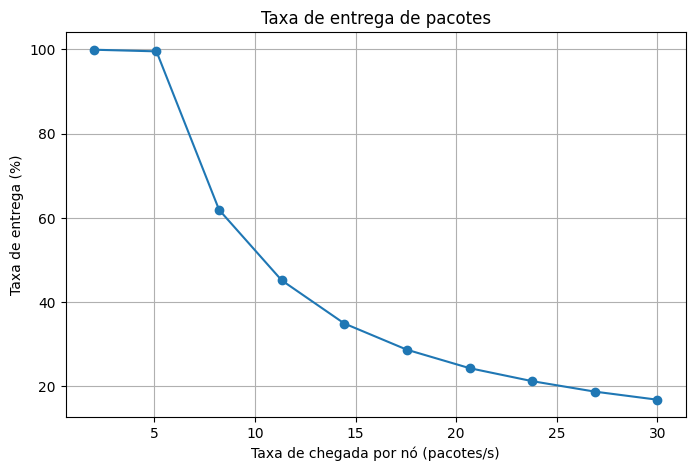

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["arrival_rate_per_node"], df_results["delivery_rate_percent"], marker="o")
plt.xlabel("Taxa de chegada por nó (pacotes/s)")
plt.ylabel("Taxa de entrega (%)")
plt.title("Taxa de entrega de pacotes")
plt.grid(True)
plt.show()

## Throughput efetivo

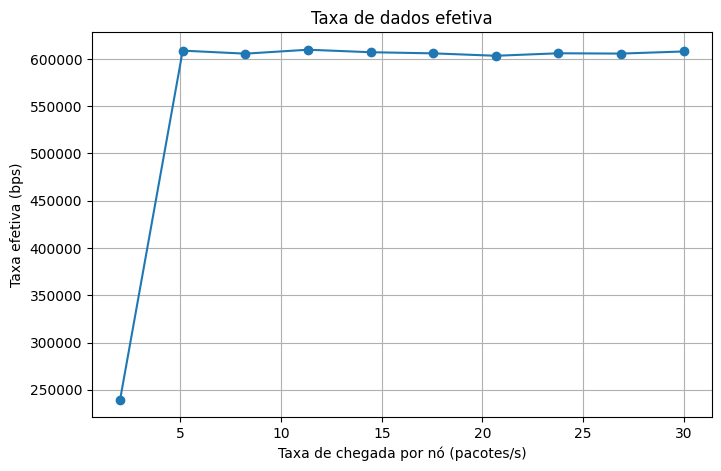

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["arrival_rate_per_node"], df_results["throughput_bps"], marker="o")
plt.xlabel("Taxa de chegada por nó (pacotes/s)")
plt.ylabel("Taxa efetiva (bps)")
plt.title("Taxa de dados efetiva")
plt.grid(True)
plt.show()

## Latência média

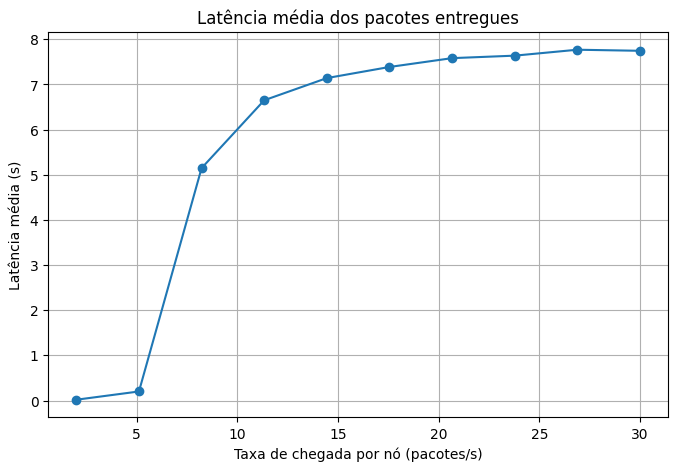

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["arrival_rate_per_node"], df_results["avg_latency_s"], marker="o")
plt.xlabel("Taxa de chegada por nó (pacotes/s)")
plt.ylabel("Latência média (s)")
plt.title("Latência média dos pacotes entregues")
plt.grid(True)
plt.show()

## Ocupação média do buffer

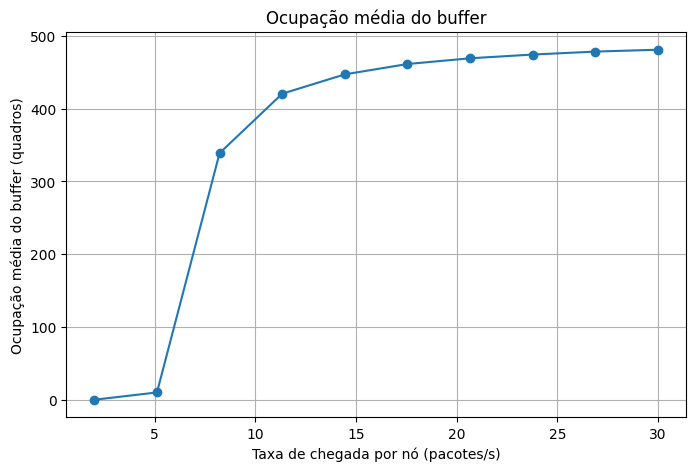

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["arrival_rate_per_node"], df_results["avg_buffer_occupancy"], marker="o")
plt.xlabel("Taxa de chegada por nó (pacotes/s)")
plt.ylabel("Ocupação média do buffer (quadros)")
plt.title("Ocupação média do buffer")
plt.grid(True)
plt.show()

## Ocupação máxima do buffer

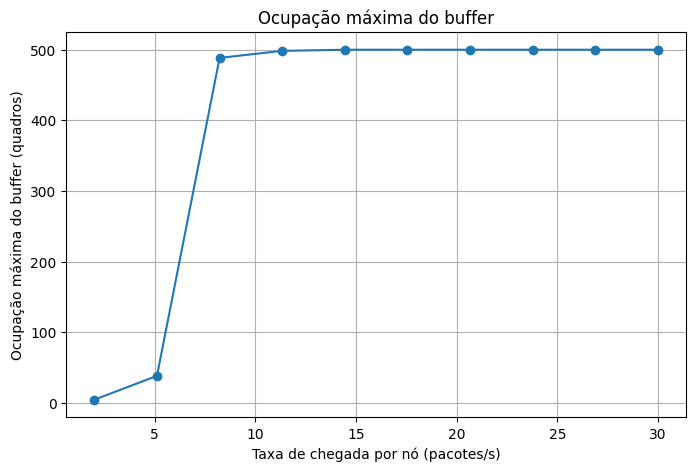

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["arrival_rate_per_node"], df_results["max_buffer_occupancy"], marker="o")
plt.xlabel("Taxa de chegada por nó (pacotes/s)")
plt.ylabel("Ocupação máxima do buffer (quadros)")
plt.title("Ocupação máxima do buffer")
plt.grid(True)
plt.show()

## Tabela final resumida

In [15]:
df_results_rounded = df_results.copy()
for col in ["delivery_rate_percent", "throughput_bps", "avg_latency_s", "avg_buffer_occupancy", "max_buffer_occupancy"]:
    df_results_rounded[col] = df_results_rounded[col].round(4)

df_results_rounded

,arrival_rate_per_node,generated_packets,delivered_packets,dropped_packets,collided_packets,delivery_rate_percent,throughput_bps,avg_latency_s,avg_buffer_occupancy,max_buffer_occupancy
0,2.000000,599.2,598.8,0.0,23.2,99.9316,239520.0,0.0173,0.3468,4.4
1,5.111111,1529.0,1522.0,0.0,908.0,99.5441,608800.0,0.2002,10.3426,38.2
2,8.222222,2446.2,1514.0,455.8,1982.4,61.9243,605600.0,5.1469,338.9010,488.4
3,11.333333,3374.6,1524.4,1365.4,1968.6,45.1839,609760.0,6.6498,420.4393,498.4
4,14.444444,4345.0,1517.8,2334.0,1964.4,34.9374,607120.0,7.1410,447.0055,500.0
5,17.555556,5276.6,1514.8,3267.2,1979.8,28.7127,605920.0,7.3870,461.2083,500.0
6,20.666667,6199.0,1508.4,4194.0,1995.4,24.3394,603360.0,7.5827,469.0875,500.0
7,23.777778,7129.2,1515.0,5116.2,1976.0,21.2526,606000.0,7.6378,474.2158,500.0
8,26.888889,8068.8,1514.2,6057.2,1985.0,18.7683,605680.0,7.7692,478.2748,500.0
9,30.000000,9022.4,1519.8,7004.6,1965.8,16.8474,607920.0,7.7454,480.8399,500.0


## Interpretação esperada dos resultados

À medida que a carga oferecida por nó aumenta, a rede tende a apresentar maior contenção pelo meio. Em cargas baixas, a taxa de entrega tende a permanecer alta, com baixa latência e baixa ocupação de buffer. Conforme a carga cresce, aumentam as colisões, o tempo de espera por backoff, a latência média e a ocupação dos buffers. A taxa efetiva cresce inicialmente, mas depois tende à saturação, podendo até estabilizar ou piorar dependendo da intensidade da contenção.